## Reproductible fitting for the `jmstate` package

In [1]:
%pip install jmstate==0.11.2 pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


In [3]:
torch.manual_seed(42)


TAU = 7.5


def reg(t: torch.Tensor, psi: torch.Tensor):
    b, w1, w2 = psi.chunk(3, dim=-1)  # Extract relevant terms

    # psi has shape (n_chains, n_individuals, n_repetitions)
    return (b + w1 * t + (w2 - w1) * (t > TAU) * (t - TAU)).unsqueeze(-1)


def link(t: torch.Tensor, psi: torch.Tensor):
    b, w1, w2 = psi.chunk(3, dim=-1)

    diff = (w2 - w1) * (t > TAU)
    val = b + w1 * t + diff * (t - TAU)
    der = w1 + diff
    return torch.cat([val.unsqueeze(-1), der.unsqueeze(-1)], dim=-1)


def random_far_apart(
    n: int, m: int, a: torch.Tensor, b: torch.Tensor, min_dist: torch.Tensor
):
    L_free = (b - a) - (m - 1) * min_dist

    y = torch.rand(n, m) * L_free
    y, _ = torch.sort(y, dim=1)

    gap_offset = torch.arange(m) * min_dist

    return a + y + gap_offset

In [4]:
from jmstate.functions.base_hazards import Exponential
from jmstate.functions.individual_effects import gamma_plus_b
from jmstate.types import ModelDesign

# Survival model specification
surv_fns = {
    (0, 1): (Exponential(1e-3), link),
    (0, 2): (Exponential(1e-4), link),
    (1, 2): (Exponential(1e-4), link),
}

# Model design gathers regression, link and hazard functions
model_design = ModelDesign(gamma_plus_b, reg, surv_fns)

In [5]:
from jmstate.types import CovParameters, ModelParameters

# Gaussian means
gamma = torch.tensor([2.5, -1.3, 0.2])

# Covariance matrices
Q = torch.diag(torch.tensor([0.6, 0.2, 0.3]))
R = torch.tensor([[1.7]])

# Link parameters
alphas = {
    (0, 1): torch.tensor([-0.5, -1.0]),
    (0, 2): torch.tensor([-1.0, -0.5]),
    (1, 2): torch.tensor([-1.0, 0.0]),
}

# Covariate parameters
betas = {
    (0, 1): torch.tensor([-1.3]),
    (0, 2): torch.tensor([-0.9]),
    (1, 2): torch.tensor([-0.7]),
}

# Instance declaration
true_parameters = ModelParameters(
    gamma,
    CovParameters.from_cov(Q, covariance_type="diag"),
    CovParameters.from_cov(R, covariance_type="spherical"),
    alphas,
    betas,
)


In [6]:
from jmstate import MultiStateJointModel
from jmstate.types import ModelData, SampleData
from torch.distributions import MultivariateNormal

# Declare the true underlying model
true_model = MultiStateJointModel(model_design, true_parameters)


def gen_data(n: int, m: int):
    # Censoring times
    c = torch.rand(n, 1) * 5 + 10

    # Covariates
    x = torch.randn(n, 1)

    # Latent and noise distributions
    Q_dist = MultivariateNormal(torch.zeros(Q.size(0)), Q)
    R_dist = MultivariateNormal(torch.zeros(R.size(0)), R)

    # Individual effects
    b = Q_dist.sample((n,))
    psi = model_design.individual_effects_fn(gamma, x, b)

    # Generates random evaluations points with a minimum distance
    a = torch.zeros((n, 1))
    b = torch.full((n, 1), 15)
    t = random_far_apart(n, m, a, b, 0.7 * b / m)

    # Defines initial state for individuals
    trajectories_init = [[(0.0, 0)] for _ in range(n)]

    # Samples trajectories
    sample_data = SampleData(x, trajectories_init, psi)
    trajectories = true_model.sample_trajectories(sample_data, c)

    # Samples longitudinal values
    y = model_design.regression_fn(t, psi)
    y += R_dist.sample(y.shape[:2])

    # Censors longitudinal measurements exceeding censoring times
    y[t > c] = torch.nan

    return x, t, y, trajectories, c


data = ModelData(*gen_data(1000, 20))

In [7]:
from jmstate.utils import build_buckets

buckets = build_buckets(data.trajectories)
print({key: val.idxs.numel() for key, val in buckets.items()})


{(0, 1): 300, (0, 2): 316, (1, 2): 216}


In [8]:
# Declares initial parameters; zero mean and unit variance
def init_params():
    return ModelParameters(
        torch.zeros_like(gamma),
        CovParameters.from_cov(torch.eye(Q.size(0)), "diag"),
        CovParameters.from_cov(torch.eye(R.size(0)), "spherical"),
        {k: torch.zeros_like(v) for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


# Misspecified parameters (too few)
def init_params_less():
    alpha_shared = torch.zeros(2)

    return ModelParameters(
        torch.zeros_like(gamma),
        CovParameters.from_cov(torch.eye(Q.size(0)), "diag"),
        CovParameters.from_cov(torch.eye(R.size(0)), "spherical"),
        {k: alpha_shared for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


# Misspecified parameters (too many)
def init_params_more():
    return ModelParameters(
        torch.zeros_like(gamma),
        CovParameters.from_cov(torch.eye(Q.size(0)), "full"),
        CovParameters.from_cov(torch.eye(R.size(0)), "spherical"),
        {k: torch.zeros_like(v) for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


In [9]:
from jmstate.utils import summary

# Declares initial model
params = init_params()
optimizer = torch.optim.Adam(params.parameters(), lr=0.5, amsgrad=True)
model = MultiStateJointModel(model_design, params, optimizer)

# Runs optimization process
model.fit(data)

# Prints relevant information
summary(model)

Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:12<00:00,  8.11it/s]


╭───────────────────────────────────── Model Summary ─────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name   ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ gamma[0]         │ 2.453  │     0.034      │ 72.898  │  0.000  │        ***         │ │
│ │ gamma[1]         │ -1.286 │     0.014      │ 93.415  │  0.000  │        ***         │ │
│ │ gamma[2]         │ 0.195  │     0.020      │  9.949  │  0.000  │        ***         │ │
│ │ q.flat[0]        │ 0.278  │     0.042      │  6.651  │  0.000  │        ***         │ │
│ │ q.flat[1]        │ 0.823  │     0.026      │ 31.369  │  0.000  │        ***         │ │
│ │ q.flat[2]        │ 0.613  │     0.029      │ 20.857  │  0.000  │        ***         │ │
│ │ r.flat[0]        │ -0.284 │     0.006      │ 45.892  │  0.000  │        ***         │ │
│ │ alphas.(0, 1)[0] │ -0.555 │     0.020      │ 27.501  │  0.000  │        ***         │ │
│ │ alphas.(0, 1)[1] │ -0.912 │     0.085      │ 10.681  │  0.000  │        ***         │ │
│ │ alphas.(0, 2)[0] │ -0.991 │     0.016      │ 61.170  │  0.000  │        ***         │ │
│ │ alphas.(0, 2)[1] │ -0.549 │     0.082      │  6.685  │  0.000  │        ***         │ │
│ │ alphas.(1, 2)[0] │ -1.020 │     0.017      │ 61.184  │  0.000  │        ***         │ │
│ │ alphas.(1, 2)[1] │ -0.148 │     0.090      │  1.654  │  0.098  │         .          │ │
│ │ betas.(0, 1)[0]  │ -1.179 │     0.063      │ 18.678  │  0.000  │        ***         │ │
│ │ betas.(0, 2)[0]  │ -0.974 │     0.071      │ 13.675  │  0.000  │        ***         │ │
│ │ betas.(1, 2)[0]  │ -0.539 │     0.090      │  6.012  │  0.000  │        ***         │ │
│ └──────────────────┴────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ─────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: -33051.120                                                              │
│ AIC: 66134.240                                                                          │
│ BIC: 66215.061                                                                          │
│ ─────────────────────────────────────────────────────────────────────────────────────── │
╰─────────────────────────────────────────────────────────────────────────────────────────╯

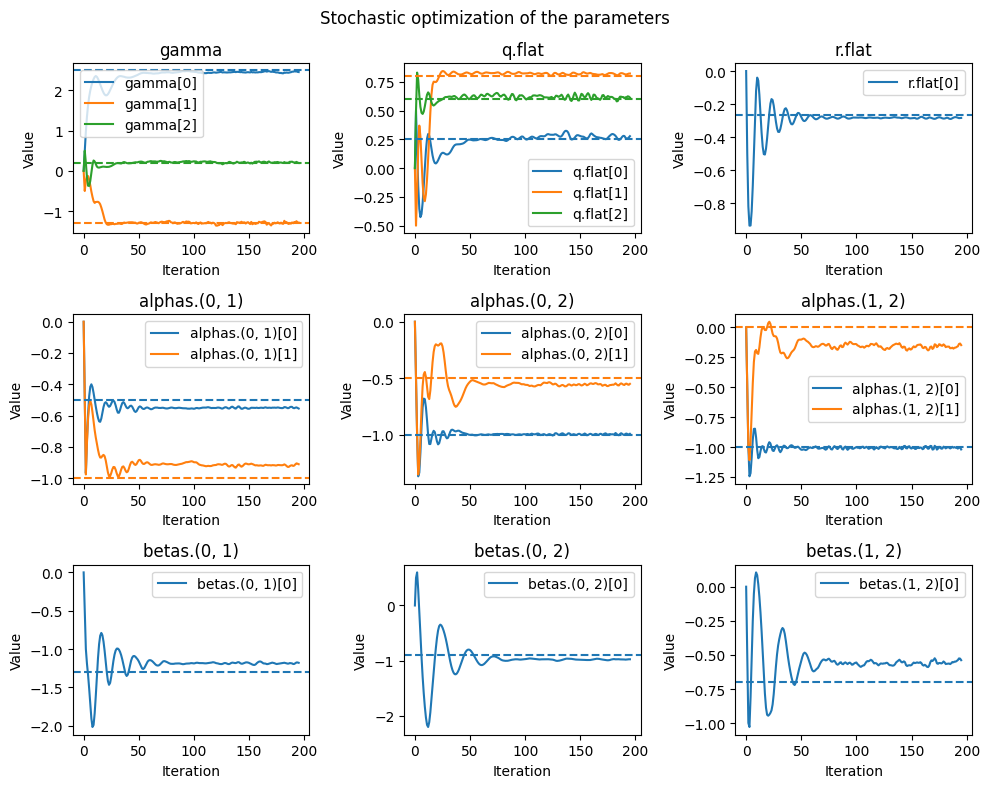

In [10]:
from jmstate.utils import plot_params_history

fig, axes = plot_params_history(model)

# Add true parameters
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for ax, param in zip(list(axes), true_parameters.parameters(), strict=False):
    for i, p in enumerate(param):
        ax.axhline(y=p.detach(), c=colors[i], linestyle="--")

plt.savefig("../figures/stochastic-optimization.pdf")
plt.show()

In [11]:
from jmstate.utils import parameters_to_vector
from tqdm import trange


def get_vector_and_scores(parameters_factory, data):
    parameters = parameters_factory()
    optimizer = torch.optim.Adam(parameters.parameters(), lr=0.5, amsgrad=True)
    model = MultiStateJointModel(
        model_design, parameters, optimizer, verbose=False
    ).fit(data)

    return parameters_to_vector(model.parameters()), model.aic_, model.bic_


# Define competing models
parameters_factories = {
    "equal": init_params,
    "less": init_params_less,
    "more": init_params_more,
}
n_redo = 100

# Storage for results
all_results = defaultdict(list)

for _ in trange(n_redo):
    # Generate new data for this redo
    data = ModelData(*gen_data(1000, 20))

    for name, factory in parameters_factories.items():
        vec, aic, bic = get_vector_and_scores(factory, data)
        all_results[name].append({"vec": vec, "aic": aic, "bic": bic})

# Extract Param vectors, AICs, and BICs for analysis
vecs = {name: [r["vec"] for r in all_results[name]] for name in parameters_factories}
aics = {name: [r["aic"] for r in all_results[name]] for name in parameters_factories}
bics = {name: [r["bic"] for r in all_results[name]] for name in parameters_factories}


100%|██████████| 100/100 [1:58:23<00:00, 71.03s/it]


In [19]:
true_params_vec = parameters_to_vector(true_parameters.parameters()).detach().numpy()

# Compute statistics
stacked_params = torch.stack(vecs["equal"]).detach().numpy()
bias = stacked_params.mean(axis=0) - true_params_vec
std = stacked_params.std(axis=0)
rmse = np.sqrt(std**2 + bias**2)

# Put as a dict
convergence = {
    "True value": true_params_vec,
    "Bias": bias,
    "Std deviation": std,
    "RMSE": rmse,
}

# Set names for the dataframe
named_parameters_dict = dict(true_parameters.named_parameters())
index = [
    f"{name}[{j}]"
    for name, param in named_parameters_dict.items()
    for j in range(param.numel())
]

# Create datagrame
convergence_df = pd.DataFrame(convergence, index=index)
pd.set_option("display.float_format", "{:.3}".format)
convergence_df.to_csv("../results/convergence-results.txt")

print(convergence_df)

                  True value     Bias  Std deviation    RMSE
gamma[0]                 2.5  -0.0057         0.0368  0.0372
gamma[1]                -1.3 -0.00247         0.0275  0.0276
gamma[2]                 0.2  -0.0026         0.0227  0.0228
q.flat[0]              0.255  -0.0189         0.0434  0.0473
q.flat[1]              0.805 0.000158         0.0256  0.0256
q.flat[2]              0.602 -0.00695         0.0346  0.0352
r.flat[0]             -0.265 -0.00144        0.00732 0.00746
alphas.(0, 1)[0]        -0.5 -0.00676         0.0225  0.0235
alphas.(0, 1)[1]        -1.0   0.0365          0.099   0.106
alphas.(0, 2)[0]        -1.0 -0.00409         0.0145  0.0151
alphas.(0, 2)[1]        -0.5   0.0227         0.0667  0.0705
alphas.(1, 2)[0]        -1.0 -0.00154         0.0235  0.0235
alphas.(1, 2)[1]         0.0   0.0098          0.102   0.103
betas.(0, 1)[0]         -1.3  -0.0146         0.0732  0.0746
betas.(0, 2)[0]         -0.9 -0.00607         0.0714  0.0717
betas.(1, 2)[0]         

In [ ]:
# Build a dataframe where rows = redo, columns = model
df_aic = pd.DataFrame(aics)
df_bic = pd.DataFrame(bics)

# For each redo, find which model has the minimum
winners_aic = df_aic.idxmin(axis=1)
winners_bic = df_bic.idxmin(axis=1)

# Count how many times each model wins
counts_df = (
    pd.DataFrame(
        {
            "AIC": winners_aic.value_counts(),
            "BIC": winners_bic.value_counts(),
        }
    )
    .fillna(0)
    .astype(int)
)
counts_df.to_csv("../results/selection-results.txt")

print(counts_df)

       AIC  BIC
equal   81   92
more    19    8
